In [ ]:
!pip install xgboost statsmodels

import sections

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

load the data

In [ ]:
!unzip "/content/archive (4).zip"

Archive:  /content/archive (4).zip
  inflating: Walmart_Sales.csv       


In [ ]:
df=pd.read_csv("Walmart_Sales.csv")
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.groupby('Weekly_Sales')['Holiday_Flag'].mean()

,Holiday_Flag
Weekly_Sales,
209986.25,0.0
213538.32,0.0
215359.21,1.0
219804.85,1.0
220060.35,0.0
...,...
3595903.20,0.0
3676388.98,0.0
3749057.69,0.0


<Axes: xlabel='Weekly_Sales', ylabel='Fuel_Price'>

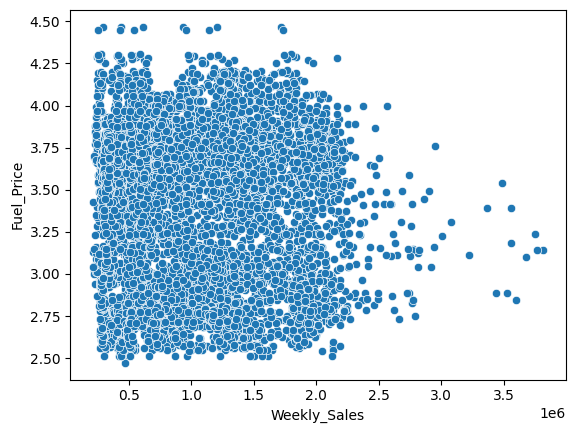

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df.plot(x='Weekly_Sales',y='Fuel_Price',kind='scatter')
sns.scatterplot(x='Weekly_Sales',y='Fuel_Price',data=df)

Average Sales - Regular Weeks vs Holiday Weeks:
   Holiday_Flag  Weekly_Sales
0             0  1.033918e+06
1             1  1.121632e+06


/tmp/ipykernel_3674/1743360391.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df_clean, palette='Blues_d')


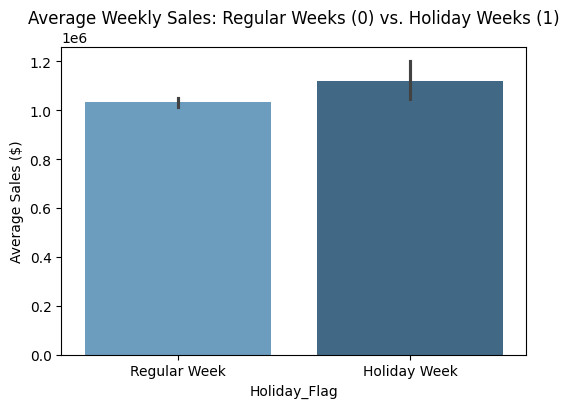

In [ ]:


# 1. Calculate average sales
holiday_sales = df_clean.groupby('Holiday_Flag')['Weekly_Sales'].mean().reset_index()
print("Average Sales - Regular Weeks vs Holiday Weeks:")
print(holiday_sales)

# 2. Plot the difference
plt.figure(figsize=(6, 4))
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df_clean, palette='Blues_d')
plt.title('Average Weekly Sales: Regular Weeks (0) vs. Holiday Weeks (1)')
plt.xticks([0, 1], ['Regular Week', 'Holiday Week'])
plt.ylabel('Average Sales ($)')
plt.show()

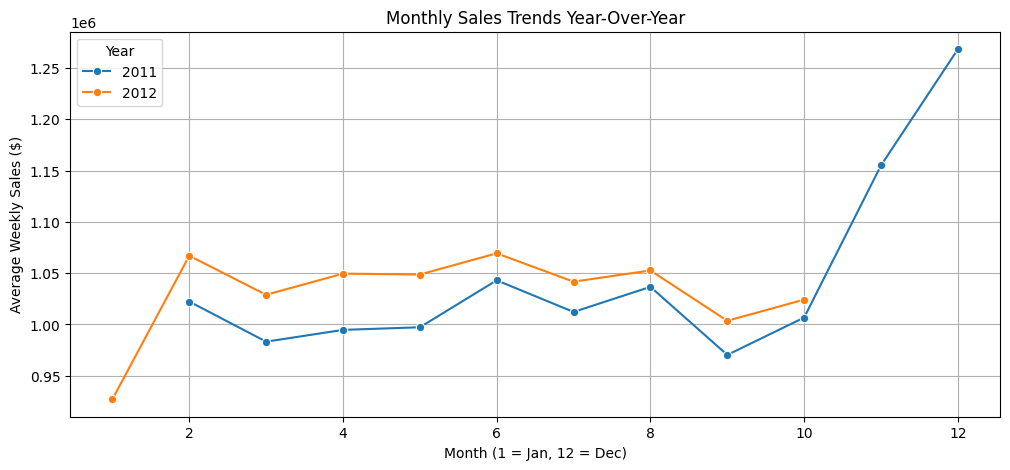

In [ ]:
# Group by Year and Month to see the timeline
monthly_sales = df_clean.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x='Month', y='Weekly_Sales', hue='Year', data=monthly_sales, marker='o', palette='tab10')
plt.title('Monthly Sales Trends Year-Over-Year')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Average Weekly Sales ($)')
plt.grid(True)
plt.show()

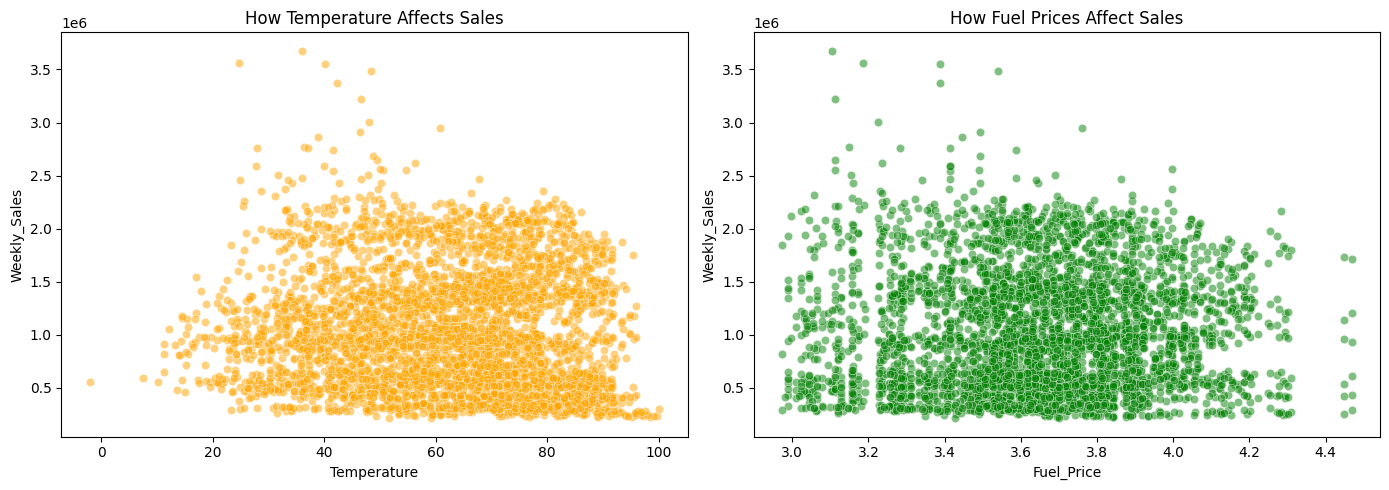

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature vs Sales
sns.scatterplot(ax=axes[0], x='Temperature', y='Weekly_Sales', data=df_clean, alpha=0.5, color='orange')
axes[0].set_title('How Temperature Affects Sales')

# Fuel Price vs Sales
sns.scatterplot(ax=axes[1], x='Fuel_Price', y='Weekly_Sales', data=df_clean, alpha=0.5, color='green')
axes[1].set_title('How Fuel Prices Affect Sales')

plt.tight_layout()
plt.show()

create Lag_features

In [ ]:
# 1. Create lag features correctly by grouping by Store
df['last_week'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['two_weeks_ago'] = df.groupby('Store')['Weekly_Sales'].shift(2)
df['last_month'] = df.groupby('Store')['Weekly_Sales'].shift(4)
df['quater_month'] = df.groupby('Store')['Weekly_Sales'].shift(13)
df['last_year'] = df.groupby('Store')['Weekly_Sales'].shift(52)

# 2. Drop the rows containing NaN values from these remaining lag columns
df_clean = df.dropna().copy()

# 3. Print the shapes to see how much clean data you preserved
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
df_clean.head()

Original shape: (6435, 14)
Cleaned shape: (4043, 14)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,last_week,two_weeks_ago,last_month,quater_month,last_year,two_years_ago
104,1,03-02-2012,1636339.65,0,56.55,3.360,220.172015,7.348,1319325.59,1394393.84,1550369.92,1697229.58,1606629.58,1643690.90
105,1,10-02-2012,1802477.43,1,48.02,3.409,220.265178,7.348,1636339.65,1319325.59,1459601.17,1594938.89,1649614.93,1641957.44
106,1,17-02-2012,1819870.00,0,45.32,3.510,220.425759,7.348,1802477.43,1636339.65,1394393.84,1539483.70,1686842.78,1611968.17
107,1,24-02-2012,1539387.83,0,57.25,3.555,220.636902,7.348,1819870.00,1802477.43,1319325.59,2033320.66,1456800.28,1409727.59
108,1,02-03-2012,1688420.76,0,60.96,3.630,220.848045,7.348,1539387.83,1819870.00,1636339.65,1584083.95,1636263.41,1554806.68


covert string date to date,month,year sperate columns

In [ ]:
# 1. Convert Date column to datetime format explicitly matching day-month-year
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d-%m-%Y')

# 2. Extract numerical features from the datetime object
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Week'] = df_clean['Date'].dt.isocalendar().week.astype(int)

# 3. View the new columns at the end of your dataframe
df_clean[['Date', 'Year', 'Month', 'Week']].head()

,Date,Year,Month,Week
104,2012-02-03,2012,2,5
105,2012-02-10,2012,2,6
106,2012-02-17,2012,2,7
107,2012-02-24,2012,2,8
108,2012-03-02,2012,3,9


split data by the time

In [ ]:
# 1. Sort the data chronologically to prevent any time leaks
df_clean = df_clean.sort_values(by=['Store', 'Date'])

# 2. Chronological Train-Test Split
split_date = '2012-08-01'
train = df_clean[df_clean['Date'] < split_date]
test = df_clean[df_clean['Date'] >= split_date]

# 3. Define your input features (X) and target variable (y)
features = [
    'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'last_week', 'two_weeks_ago', 'last_month', 'quater_month', 'last_year',
    'Year', 'Month', 'Week'
]
target = 'Weekly_Sales'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 4. Initialize and Train the XGBoost Model
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

[0]	validation_0-rmse:501580.77936
[100]	validation_0-rmse:57574.88291
[200]	validation_0-rmse:59869.15092
[300]	validation_0-rmse:61131.41251
[400]	validation_0-rmse:62277.93938
[499]	validation_0-rmse:62574.06267


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

metrics score

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score
# 1. This is your familiar step: get the final predictions
y_pred = model.predict(X_test)

# 2. Calculate your final performance metrics

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Mean Absolute Error (MAE): $40,876.58
Root Mean Squared Error (RMSE): $62,574.06


reset the model for optimal solution

In [ ]:
model_optimized=XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42,early_stopping_rounds=50)
#re fit the model
model_optimized.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
y_pred_opt=model_optimized.predict(X_test)
print(f"Optimized MAE: ${mean_absolute_error(y_test, y_pred_opt):,.2f}")

[0]	validation_0-rmse:501580.77936
[100]	validation_0-rmse:57574.88291
[122]	validation_0-rmse:58451.93015
Optimized MAE: $38,593.04


plot the data

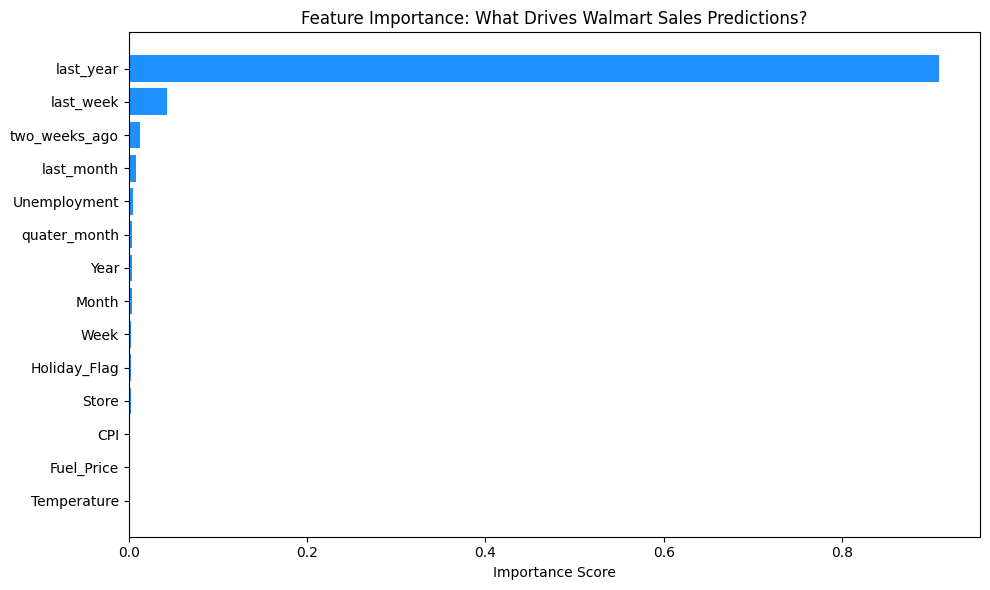

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract feature importances from your optimized model
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model_optimized.feature_importances_
}).sort_values(by='Importance', ascending=True)

# 2. Plot a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='dodgerblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance: What Drives Walmart Sales Predictions?')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

# 1. Save and download the cleaned data file
df_clean.to_csv('walmart_cleaned_data.csv', index=False)
files.download('walmart_cleaned_data.csv')

# 2. Save and download your optimized XGBoost model file
model_optimized.save_model('xgb_walmart_model.json')
files.download('xgb_walmart_model.json')

# 3. Create and download requirements.txt for Streamlit
requirements_code = "streamlit\npandas\nnumpy\nxgboost\nmatplotlib\nseaborn\nscikit-learn"
with open('requirements.txt', 'w') as f:
    f.write(requirements_code)
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

st.set_page_config(page_title="Walmart Sales Forecast", layout="wide", page_icon="📊")

st.title("📊 Walmart Executive Sales Forecasting Dashboard")
st.markdown("---")

@st.cache_data
def load_data():
    df = pd.read_csv('walmart_cleaned_data.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    return df

@st.cache_resource
def load_model():
    model = XGBRegressor()
    model.load_model('xgb_walmart_model.json')
    return model

try:
    df_clean = load_data()
    model_optimized = load_model()
except Exception as e:
    st.error(f"Error loading files. Ensure they are uploaded to your GitHub repository. Error: {e}")
    st.stop()

# Business Summary
st.subheader("💡 Core Business Discoveries")
col1, col2, col3 = st.columns(3)
with col1:
    st.info("**The Holiday Surge**\\n\\nHoliday weeks generate an average of **$1,121,632**, compared to **$1,033,918** during regular weeks. That's a consistent **+$87,714 revenue boost** per store.")
with col2:
    st.success("**The Historical Anchor**\\n\\nOur machine learning model discovered that **`last_year` sales** is your #1 strongest predictor. Shopping habits follow strict annual routines.")
with col3:
    st.warning("**External Immunity**\\n\\nData shows shifts in **Temperature** or **Fuel Prices** have almost **zero impact** on final weekly revenue. Walmart is an insulated necessity.")

st.markdown("---")

# Interactive Sidebar Filter
st.sidebar.header("🛠️ Store Analytics Filter")
selected_store = st.sidebar.selectbox("Select a Store to Inspect:", sorted(df_clean['Store'].unique()))
store_df = df_clean[df_clean['Store'] == selected_store]
avg_weekly_sales = store_df['Weekly_Sales'].mean()
st.sidebar.metric(label=f"Avg Weekly Sales (Store {selected_store})", value=f"${avg_weekly_sales:,.2f}")

# Visual Charts
st.subheader("📈 Trend Visualizations")
tab1, tab2 = st.tabs(["📅 Seasonality & Holidays", "⚙️ Model Decision Drivers"])

with tab1:
    col_chart1, col_chart2 = st.columns(2)
    with col_chart1:
        st.write("#### Regular Weeks vs. Holiday Weeks Average")
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df_clean, palette='Blues_d', ax=ax, hue='Holiday_Flag', legend=False)
        ax.set_xticklabels(['Regular Week', 'Holiday Week'])
        ax.set_ylabel('Average Sales ($)')
        st.pyplot(fig)

    with col_chart2:
        st.write("#### Year-Over-Year Monthly Performance")
        monthly_sales = df_clean.groupby([df_clean['Date'].dt.year, df_clean['Date'].dt.month])['Weekly_Sales'].mean().reset_index()
        monthly_sales.columns = ['Year', 'Month', 'Weekly_Sales']
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.lineplot(x='Month', y='Weekly_Sales', hue='Year', data=monthly_sales, marker='o', palette='tab10', ax=ax)
        ax.set_xlabel('Month (1 = Jan, 12 = Dec)')
        ax.set_ylabel('Sales ($)')
        ax.grid(True, linestyle='--')
        st.pyplot(fig)

with tab2:
    st.write("#### What Variables Direct the Artificial Intelligence Forecast?")
    features_list = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'last_week', 'two_weeks_ago', 'last_month', 'quater_month', 'last_year', 'Year', 'Month', 'Week']
    importance_df = pd.DataFrame({
        'Feature': features_list,
        'Importance': model_optimized.feature_importances_
    }).sort_values(by='Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.barh(importance_df['Feature'], importance_df['Importance'], color='dodgerblue')
    ax.set_xlabel('Importance Score')
    st.pyplot(fig)

st.markdown("---")

# Predictive Calculator Form
st.subheader("🔮 Run a Live Sales Forecast")
pred_col1, pred_col2, pred_col3 = st.columns(3)

with pred_col1:
    inp_holiday = st.selectbox("Is it a Holiday Week?", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
    inp_temp = st.number_input("Expected Temperature (°F):", value=60.0)
    inp_fuel = st.number_input("Expected Fuel Price ($/Gal):", value=3.50)

with pred_col2:
    inp_cpi = st.number_input("Current CPI (Inflation Index):", value=220.0)
    inp_unemp = st.number_input("Local Unemployment Rate (%):", value=7.0)
    inp_week = st.slider("Week Number of the Year:", min_value=1, max_value=52, value=45)

with pred_col3:
    inp_last_week = st.number_input("Sales Last Week ($):", value=float(store_df['last_week'].median()))
    inp_last_year = st.number_input("Sales Exactly 1 Year Ago ($):", value=float(store_df['last_year'].median()))

inp_two_weeks = store_df['two_weeks_ago'].median()
inp_last_month = store_df['last_month'].median()
inp_quarter = store_df['quater_month'].median()
inp_month = int(np.clip(inp_week // 4.3, 1, 12))
inp_year = 2012

if st.button("🚀 Calculate Future Revenue Estimate"):
    input_features = np.array([[
        selected_store, inp_holiday, inp_temp, inp_fuel, inp_cpi, inp_unemp,
        inp_last_week, inp_two_weeks, inp_last_month, inp_quarter, inp_last_year,
        inp_year, inp_month, inp_week
    ]])
    prediction = model_optimized.predict(input_features)[0]
    st.balloons()
    st.success(f"### Predicted Weekly Revenue: **${prediction:,.2f}**")

Writing app.py


In [ ]:
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
from google.colab import files

# 1. Serialize and save the model as a .pkl file
with open('model.pkl', 'wb') as f:
    pickle.dump(model_optimized, f)

print("model.pkl saved to Colab session storage.")

# 2. Trigger the automatic browser download
files.download('model.pkl')

model.pkl saved to Colab session storage.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>